# Notebook 03: Backtest & Evaluation

**Purpose:** Compare the DQN v2 agent against static and adaptive baselines on the held-out test period (2020-2023).

**Strategies compared:**
1. Static gamma=1.0 (ORCA's approach)
2. Static gamma=1.5 (tighter threshold)
3. Adaptive VIX (rule-based: scale threshold by VIX regime)
4. DQN v2 Agent (3 actions: flat/long/short, fixed 10% sizing)

**Test period:** 2020-01-01 to 2023-12-31 (COVID crash + rate hikes — never seen during training)

**Key:** All strategies use identical 10% capital position sizing for fair comparison.
The only difference is entry/exit timing decisions.

**To reproduce:** Run `python run_backtest_v2.py` for the full comparison with statistical tests.

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import pickle
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

In [2]:
# --- Load all artifacts ---
with open('datasets/nb02_artifacts.pkl', 'rb') as f:
    artifacts = pickle.load(f)

scaler = artifacts['scaler']
pca = artifacts['pca']
cointegrated_pairs = artifacts['cointegrated_pairs']
STATIC_FEATURE_COLS = artifacts['STATIC_FEATURE_COLS']
ORIGINAL_PAIRS = [f"{a}/{b}" for a, b in artifacts['ORIGINAL_PAIRS']]
STATE_DIM = artifacts['state_dim']
ACTION_DIM = 7

# Load data
spreads_df = pd.read_parquet('datasets/spreads.parquet')
all_features = {}
all_ou_params = {}
for pair_name in cointegrated_pairs:
    safe = pair_name.replace('/', '_')
    all_features[pair_name] = pd.read_parquet(f'datasets/features_{safe}.parquet')
    all_ou_params[pair_name] = pd.read_parquet(f'datasets/ou_params_{safe}.parquet')

df_prices = pd.read_parquet('datasets/pair_prices.parquet')

print(f"Loaded {len(cointegrated_pairs)} cointegrated pairs")
print(f"Original 5 pairs for highlight: {ORIGINAL_PAIRS}")

Loaded 19 cointegrated pairs
Original 5 pairs for highlight: ['KO/PEP', 'XOM/CVX', 'JPM/GS', 'WMT/TGT', 'AAPL/MSFT']


In [3]:
# --- Load trained DQN model ---
# Redefine QNetwork (must match notebook 03)
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim=7, dropout=0.2):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(state_dim, 128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, action_dim)
        )
    def forward(self, x):
        return self.network(x)

checkpoint = torch.load('dqn_pairs_agent.pt', map_location='cpu', weights_only=False)
dqn_model = QNetwork(STATE_DIM, ACTION_DIM, dropout=0.0)  # no dropout at inference
dqn_model.load_state_dict(checkpoint['model_state_dict'])
dqn_model.eval()

fold_sharpes = checkpoint.get('fold_results', [])
print(f"DQN model loaded. CV validation Sharpes: {fold_sharpes}")

DQN model loaded. CV validation Sharpes: [{'fold': 1, 'val_sharpe': np.float64(1.1628708321514856)}, {'fold': 2, 'val_sharpe': np.float64(1.1225540888347927)}, {'fold': 3, 'val_sharpe': np.float64(0.46360808520979174)}]


## 1. Strategy Definitions

In [4]:
ACTION_MAP = {
    0: (0, 0.00),
    1: (1, 0.25), 2: (1, 0.50), 3: (1, 1.00),
    4: (-1, 0.25), 5: (-1, 0.50), 6: (-1, 1.00),
}


def backtest_static(spread, z_threshold=1.0, exit_threshold=0.25,
                    max_days=60, tc=0.001, capital=100000.0):
    """
    Static threshold strategy (ORCA's approach, Algorithm 1).
    Enter when |Z| > z_threshold, exit when |Z| < exit_threshold or timeout.
    """
    spread = spread.dropna()
    roll_mean = spread.rolling(60).mean()
    roll_std = spread.rolling(60).std()
    z_score = ((spread - roll_mean) / roll_std.replace(0, np.nan)).dropna()
    
    portfolio = capital
    position = 0
    entry_price = 0
    days_held = 0
    position_size = 0
    
    daily_values = []
    trades = []
    
    for i, (date, z) in enumerate(z_score.items()):
        spread_val = spread.loc[date]
        
        # Track portfolio value
        unrealized = 0
        if position != 0:
            unrealized = position * (spread_val - entry_price) * position_size
            days_held += 1
        
        current_value = portfolio + unrealized
        daily_values.append({'date': date, 'value': current_value, 'position': position})
        
        # Exit conditions
        if position != 0 and (abs(z) < exit_threshold or days_held >= max_days):
            pnl = position * (spread_val - entry_price) * position_size
            cost = tc * abs(position_size) * abs(spread_val)
            portfolio += pnl - cost
            trades.append({
                'exit_date': date, 'pnl': pnl - cost, 'days_held': days_held,
                'exit_z': z, 'direction': position
            })
            position = 0
            days_held = 0
        
        # Entry conditions
        if position == 0:
            if z > z_threshold:
                position = -1  # short the spread
                entry_price = spread_val
                position_size = capital * 0.1 / max(abs(spread_val), 0.01)  # 10% of capital
                cost = tc * abs(position_size) * abs(spread_val)
                portfolio -= cost
                days_held = 0
            elif z < -z_threshold:
                position = 1  # long the spread
                entry_price = spread_val
                position_size = capital * 0.1 / max(abs(spread_val), 0.01)
                cost = tc * abs(position_size) * abs(spread_val)
                portfolio -= cost
                days_held = 0
    
    # Force close at end
    if position != 0 and len(z_score) > 0:
        last_spread = spread.iloc[-1]
        pnl = position * (last_spread - entry_price) * position_size
        portfolio += pnl
        trades.append({'exit_date': spread.index[-1], 'pnl': pnl, 'days_held': days_held,
                       'exit_z': 0, 'direction': position})
    
    return pd.DataFrame(daily_values), trades


def backtest_dqn(pair_name, model, date_start, date_end,
                 kelly_cap=0.5, tc=0.001, capital=100000.0):
    """
    DQN agent backtest with half-Kelly cap (Lecture slide 39: fractional Kelly).
    """
    feat = all_features[pair_name]
    spread_full = spreads_df[pair_name].dropna()
    
    mask = (feat.index >= date_start) & (feat.index <= date_end)
    feat_slice = feat.loc[mask]
    common_idx = spread_full.index.intersection(feat_slice.index)
    
    if len(common_idx) < 60:
        return pd.DataFrame(), []
    
    spread = spread_full.loc[common_idx]
    feat_slice = feat_slice.loc[common_idx]
    
    portfolio = capital
    position = 0
    position_size = 0.0
    entry_price = 0.0
    days_held = 0
    
    daily_values = []
    trades = []
    actions_log = []
    
    for i in range(len(common_idx) - 1):
        date = common_idx[i]
        spread_val = spread.iloc[i]
        
        # Build state
        raw = feat_slice.iloc[i:i+1][STATIC_FEATURE_COLS].values
        try:
            scaled = scaler.transform(raw)
            pca_feat = pca.transform(scaled).flatten()
        except Exception:
            pca_feat = np.zeros(pca.n_components_)
        
        unrealized_pnl_norm = 0
        if position != 0:
            unrealized_pnl_norm = position * (spread_val - entry_price) * position_size / max(portfolio, 1)
        
        state = np.concatenate([pca_feat, [
            float(position), unrealized_pnl_norm, float(days_held) / 60.0
        ]]).astype(np.float32)
        
        # Get action from DQN
        with torch.no_grad():
            q_values = model(torch.FloatTensor(state).unsqueeze(0))
            action = q_values.argmax(dim=1).item()
        
        direction, kelly_mult = ACTION_MAP[action]
        # Cap at half-Kelly (technique #5)
        kelly_mult = min(kelly_mult, kelly_cap)
        
        kf = feat_slice.iloc[i]['kelly_fraction'] if 'kelly_fraction' in feat_slice.columns else 0
        
        # Track portfolio
        unrealized = 0
        if position != 0:
            unrealized = position * (spread_val - entry_price) * position_size
            days_held += 1
        current_value = portfolio + unrealized
        
        # Get OU params for logging
        theta_val = 0
        if pair_name in all_ou_params and date in all_ou_params[pair_name].index:
            theta_val = all_ou_params[pair_name].loc[date, 'theta']
        
        vix_val = 0
        if 'VIX' in feat_slice.columns:
            vix_val = feat_slice.iloc[i]['VIX']
        
        daily_values.append({
            'date': date, 'value': current_value, 'position': position,
            'action': action, 'theta': theta_val, 'vix': vix_val, 'kelly_mult': kelly_mult
        })
        actions_log.append(action)
        
        # Execute action
        if direction == 0 and position != 0:
            pnl = position * (spread_val - entry_price) * position_size
            cost = tc * abs(position_size) * abs(spread_val)
            portfolio += pnl - cost
            trades.append({'exit_date': date, 'pnl': pnl - cost, 'days_held': days_held,
                          'direction': position})
            position = 0
            position_size = 0
            days_held = 0
        elif direction != 0 and position != direction:
            if position != 0:
                pnl = position * (spread_val - entry_price) * position_size
                cost = tc * abs(position_size) * abs(spread_val)
                portfolio += pnl - cost
                trades.append({'exit_date': date, 'pnl': pnl - cost, 'days_held': days_held,
                              'direction': position})
            target_size = kelly_mult * kf * current_value
            position = direction
            position_size = max(target_size / max(abs(spread_val), 0.01), 0)
            entry_price = spread_val
            cost = tc * abs(position_size) * abs(spread_val)
            portfolio -= cost
            days_held = 0
        
        # Force close at max days
        if days_held >= 60 and position != 0:
            pnl = position * (spread_val - entry_price) * position_size
            portfolio += pnl
            trades.append({'exit_date': date, 'pnl': pnl, 'days_held': days_held,
                          'direction': position})
            position = 0
            position_size = 0
            days_held = 0
    
    return pd.DataFrame(daily_values), trades


def backtest_random(spread, date_start, date_end, tc=0.001, capital=100000.0):
    """Random agent baseline."""
    spread = spread.dropna()
    mask = (spread.index >= date_start) & (spread.index <= date_end)
    spread = spread.loc[mask]
    
    portfolio = capital
    position = 0
    entry_price = 0
    position_size = 0
    days_held = 0
    daily_values = []
    trades = []
    
    for i, (date, spread_val) in enumerate(spread.items()):
        unrealized = 0
        if position != 0:
            unrealized = position * (spread_val - entry_price) * position_size
            days_held += 1
        daily_values.append({'date': date, 'value': portfolio + unrealized, 'position': position})
        
        action = np.random.randint(0, 7)
        direction, _ = ACTION_MAP[action]
        
        if direction == 0 and position != 0:
            pnl = position * (spread_val - entry_price) * position_size
            portfolio += pnl - tc * abs(position_size) * abs(spread_val)
            trades.append({'pnl': pnl, 'days_held': days_held, 'direction': position})
            position = 0; days_held = 0
        elif direction != 0 and position == 0:
            position = direction
            position_size = capital * 0.05 / max(abs(spread_val), 0.01)
            entry_price = spread_val
            days_held = 0
        
        if days_held >= 60 and position != 0:
            pnl = position * (spread_val - entry_price) * position_size
            portfolio += pnl
            trades.append({'pnl': pnl, 'days_held': days_held, 'direction': position})
            position = 0; days_held = 0
    
    return pd.DataFrame(daily_values), trades

print("Strategy definitions loaded.")

Strategy definitions loaded.


In [ ]:
def backtest_adaptive_vix(spread, pair_name, date_start, date_end,
                          exit_threshold=0.25, max_days=60, tc=0.001, capital=100000.0):
    """
    Adaptive VIX-scaled threshold baseline.
    
    This is the simple rule a skeptic would propose:
    'Just widen the threshold when VIX is high.'
    
    Rules:
        VIX < 20  (calm):    enter at 1.0 sigma
        VIX 20-30 (elevated): enter at 1.5 sigma
        VIX > 30  (stress):  don't trade (infinite threshold)
    
    If the DQN can't beat this, then a simple rule is sufficient
    and the RL complexity isn't justified.
    """
    spread = spread.dropna()
    mask = (spread.index >= date_start) & (spread.index <= date_end)
    spread = spread.loc[mask]
    
    roll_mean = spread.rolling(60).mean()
    roll_std = spread.rolling(60).std()
    z_score = ((spread - roll_mean) / roll_std.replace(0, np.nan)).dropna()
    
    # Get VIX for the test period
    vix = df_prices['VIX'].reindex(z_score.index).ffill()
    
    portfolio = capital
    position = 0
    entry_price = 0
    days_held = 0
    position_size = 0
    
    daily_values = []
    trades = []
    
    for i, (date, z) in enumerate(z_score.items()):
        spread_val = spread.loc[date]
        vix_val = vix.loc[date] if date in vix.index and not pd.isna(vix.loc[date]) else 20
        
        # Adaptive threshold based on VIX regime
        if vix_val > 30:
            z_threshold = np.inf  # don't trade in stress
        elif vix_val > 20:
            z_threshold = 1.5    # cautious in elevated vol
        else:
            z_threshold = 1.0    # normal in calm markets
        
        # Track portfolio value
        unrealized = 0
        if position != 0:
            unrealized = position * (spread_val - entry_price) * position_size
            days_held += 1
        
        current_value = portfolio + unrealized
        daily_values.append({'date': date, 'value': current_value, 'position': position})
        
        # Exit conditions
        if position != 0 and (abs(z) < exit_threshold or days_held >= max_days):
            pnl = position * (spread_val - entry_price) * position_size
            cost = tc * abs(position_size) * abs(spread_val)
            portfolio += pnl - cost
            trades.append({
                'exit_date': date, 'pnl': pnl - cost, 'days_held': days_held,
                'exit_z': z, 'direction': position
            })
            position = 0
            days_held = 0
        
        # Entry conditions (with adaptive threshold)
        if position == 0:
            if z > z_threshold:
                position = -1
                entry_price = spread_val
                position_size = capital * 0.1 / max(abs(spread_val), 0.01)
                cost = tc * abs(position_size) * abs(spread_val)
                portfolio -= cost
                days_held = 0
            elif z < -z_threshold:
                position = 1
                entry_price = spread_val
                position_size = capital * 0.1 / max(abs(spread_val), 0.01)
                cost = tc * abs(position_size) * abs(spread_val)
                portfolio -= cost
                days_held = 0
    
    # Force close at end
    if position != 0 and len(z_score) > 0:
        last_spread = spread.iloc[-1]
        pnl = position * (last_spread - entry_price) * position_size
        portfolio += pnl
        trades.append({'exit_date': spread.index[-1], 'pnl': pnl, 'days_held': days_held,
                       'exit_z': 0, 'direction': position})
    
    return pd.DataFrame(daily_values), trades

print("Adaptive VIX baseline defined.")
print("Rules: VIX<20 -> 1.0σ, VIX 20-30 -> 1.5σ, VIX>30 -> no trade")

## 2. Run All Backtests

In [ ]:
TEST_START = '2020-01-01'
TEST_END = '2023-12-31'

results = {}  # {pair: {strategy: (daily_df, trades)}}

for pair_name in cointegrated_pairs:
    spread = spreads_df[pair_name].dropna()
    test_spread = spread[(spread.index >= TEST_START) & (spread.index <= TEST_END)]
    
    if len(test_spread) < 100:
        print(f"  Skipping {pair_name}: insufficient test data ({len(test_spread)} days)")
        continue
    
    results[pair_name] = {}
    
    # Static strategies
    for gamma, name in [(1.0, 'Static 1.0'), (1.5, 'Static 1.5')]:
        daily, trades = backtest_static(test_spread, z_threshold=gamma)
        results[pair_name][name] = (daily, trades)
    
    # Adaptive VIX baseline
    daily, trades = backtest_adaptive_vix(spread, pair_name, TEST_START, TEST_END)
    if len(daily) > 0:
        results[pair_name]['Adaptive VIX'] = (daily, trades)
    
    # DQN agent
    daily, trades = backtest_dqn(pair_name, dqn_model, TEST_START, TEST_END)
    if len(daily) > 0:
        results[pair_name]['DQN Agent'] = (daily, trades)
    
    # Random agent
    daily, trades = backtest_random(spread, TEST_START, TEST_END)
    results[pair_name]['Random'] = (daily, trades)
    
    n_trades = {k: len(v[1]) for k, v in results[pair_name].items()}
    print(f"  {pair_name:12s}: {n_trades}")

print(f"\nBacktested {len(results)} pairs across 5 strategies.")

## 3. Performance Metrics

In [6]:
def compute_metrics(daily_df, trades, rf_annual=0.04):
    """Compute standard trading metrics matching ORCA Table 1."""
    if len(daily_df) < 20 or daily_df['value'].iloc[-1] <= 0:
        return None
    
    values = daily_df['value'].values
    daily_returns = np.diff(values) / values[:-1]
    daily_returns = daily_returns[np.isfinite(daily_returns)]
    
    if len(daily_returns) < 20:
        return None
    
    n_days = len(daily_returns)
    rf_daily = (1 + rf_annual) ** (1/252) - 1
    
    # Returns
    total_return = values[-1] / values[0] - 1
    ann_return = (1 + total_return) ** (252 / n_days) - 1
    ann_vol = np.std(daily_returns) * np.sqrt(252)
    
    # Risk metrics
    peak = np.maximum.accumulate(values)
    drawdown = (values - peak) / peak
    max_dd = abs(drawdown.min())
    
    # Risk-adjusted
    sharpe = (ann_return - rf_annual) / ann_vol if ann_vol > 0 else 0
    
    downside_returns = daily_returns[daily_returns < rf_daily]
    downside_vol = np.std(downside_returns) * np.sqrt(252) if len(downside_returns) > 0 else ann_vol
    sortino = (ann_return - rf_annual) / downside_vol if downside_vol > 0 else 0
    
    calmar = ann_return / max_dd if max_dd > 0 else 0
    
    # Trade-level metrics
    n_trades = len(trades)
    if n_trades > 0:
        pnls = [t['pnl'] for t in trades]
        win_rate = sum(1 for p in pnls if p > 0) / n_trades
        avg_duration = np.mean([t['days_held'] for t in trades])
        gross_profit = sum(p for p in pnls if p > 0)
        gross_loss = abs(sum(p for p in pnls if p < 0))
        profit_factor = gross_profit / gross_loss if gross_loss > 0 else np.inf
        
        # Trap rate: trades where spread moved further away (pnl < 0 after 20 days)
        trap_rate = sum(1 for p in pnls if p < 0) / n_trades
    else:
        win_rate = avg_duration = profit_factor = trap_rate = 0
    
    return {
        'AR': ann_return,
        'Vol': ann_vol,
        'MDD': max_dd,
        'Sharpe': sharpe,
        'Sortino': sortino,
        'Calmar': calmar,
        'Trap Rate': trap_rate,
        'Win Rate': win_rate,
        'Avg Duration': avg_duration,
        '# Trades': n_trades,
        'Profit Factor': min(profit_factor, 99.9),  # cap for display
    }

In [7]:
# --- Compute metrics for all strategies and pairs ---
metrics_rows = []

for pair_name, strategies in results.items():
    for strat_name, (daily, trades) in strategies.items():
        m = compute_metrics(daily, trades)
        if m is not None:
            m['Pair'] = pair_name
            m['Strategy'] = strat_name
            m['Is_Original'] = pair_name in ORIGINAL_PAIRS
            metrics_rows.append(m)

metrics_df = pd.DataFrame(metrics_rows)
print(f"Computed metrics for {len(metrics_df)} pair-strategy combinations.")

Computed metrics for 45 pair-strategy combinations.


In [ ]:
# --- Figure 7: Summary Table (mirroring ORCA Table 1) ---
# Aggregate across all pairs
agg_metrics = metrics_df.groupby('Strategy').agg({
    'AR': 'mean', 'Vol': 'mean', 'MDD': 'mean',
    'Sharpe': 'mean', 'Sortino': 'mean', 'Calmar': 'mean',
    'Trap Rate': 'mean', 'Win Rate': 'mean', 'Avg Duration': 'mean',
    '# Trades': 'sum',
}).round(4)

# Order strategies
order = ['Static 1.0', 'Static 1.5', 'Adaptive VIX', 'DQN Agent', 'Random']
agg_metrics = agg_metrics.reindex([s for s in order if s in agg_metrics.index])

print("\n" + "="*80)
print("AGGREGATE PERFORMANCE — Test Period 2020-2023 (All Pairs)")
print("Modeled after ORCA Table 1")
print("="*80)
display(agg_metrics)

# Honest assessment
print("\n--- Honest Assessment ---")
dqn_sharpe = agg_metrics.loc['DQN Agent', 'Sharpe'] if 'DQN Agent' in agg_metrics.index else 0
static_sharpe = agg_metrics.loc['Static 1.0', 'Sharpe'] if 'Static 1.0' in agg_metrics.index else 0
adaptive_sharpe = agg_metrics.loc['Adaptive VIX', 'Sharpe'] if 'Adaptive VIX' in agg_metrics.index else 0
random_sharpe = agg_metrics.loc['Random', 'Sharpe'] if 'Random' in agg_metrics.index else 0

print(f"DQN vs Static 1.0 Sharpe: {dqn_sharpe:.3f} vs {static_sharpe:.3f} "
      f"({'better' if dqn_sharpe > static_sharpe else 'WORSE'})")
print(f"DQN vs Adaptive VIX Sharpe: {dqn_sharpe:.3f} vs {adaptive_sharpe:.3f} "
      f"({'better — DQN adds value beyond simple rule' if dqn_sharpe > adaptive_sharpe else 'WORSE — simple VIX rule is sufficient'})")
print(f"DQN vs Random Sharpe: {dqn_sharpe:.3f} vs {random_sharpe:.3f} "
      f"({'better (agent learned something)' if dqn_sharpe > random_sharpe else 'WARNING: no better than random'})")

dqn_trap = agg_metrics.loc['DQN Agent', 'Trap Rate'] if 'DQN Agent' in agg_metrics.index else 0
static_trap = agg_metrics.loc['Static 1.0', 'Trap Rate'] if 'Static 1.0' in agg_metrics.index else 0
adaptive_trap = agg_metrics.loc['Adaptive VIX', 'Trap Rate'] if 'Adaptive VIX' in agg_metrics.index else 0
print(f"\nTrap Rate: Static {static_trap:.1%} -> Adaptive VIX {adaptive_trap:.1%} -> DQN {dqn_trap:.1%}")
print(f"  Adaptive VIX reduces traps by {(static_trap - adaptive_trap) / static_trap * 100:.0f}% vs static")
print(f"  DQN reduces traps by {(static_trap - dqn_trap) / static_trap * 100:.0f}% vs static")

print(f"\n--- Key Question: Does the DQN justify its complexity over a simple VIX rule? ---")
if dqn_sharpe > adaptive_sharpe and dqn_trap < adaptive_trap:
    print("YES — DQN beats the adaptive baseline on both Sharpe and trap rate.")
elif dqn_trap < adaptive_trap:
    print("PARTIALLY — DQN has lower trap rate but similar/worse Sharpe. The RL adds value for risk management.")
else:
    print("NO — The simple VIX rule captures most of the benefit. RL complexity may not be justified.")

In [ ]:
# --- Per-pair breakdown: DQN vs Static vs Adaptive VIX ---
print("\nPer-Pair Sharpe Comparison (DQN vs Static 1.0 vs Adaptive VIX):")
print("-" * 75)

dqn_vs_static = 0
dqn_vs_adaptive = 0
total_compared = 0

for pair_name in results.keys():
    pair_metrics = metrics_df[metrics_df['Pair'] == pair_name]
    dqn_row = pair_metrics[pair_metrics['Strategy'] == 'DQN Agent']
    static_row = pair_metrics[pair_metrics['Strategy'] == 'Static 1.0']
    adaptive_row = pair_metrics[pair_metrics['Strategy'] == 'Adaptive VIX']
    
    if len(dqn_row) == 0 or len(static_row) == 0:
        continue
    
    dqn_s = dqn_row.iloc[0]['Sharpe']
    static_s = static_row.iloc[0]['Sharpe']
    adaptive_s = adaptive_row.iloc[0]['Sharpe'] if len(adaptive_row) > 0 else np.nan
    
    marker = '*' if pair_name in ORIGINAL_PAIRS else ' '
    best = 'DQN' if dqn_s >= max(static_s, adaptive_s if not np.isnan(adaptive_s) else -np.inf) else \
           ('Adapt' if not np.isnan(adaptive_s) and adaptive_s >= static_s else 'Static')
    
    adapt_str = f"Adapt={adaptive_s:+.3f}" if not np.isnan(adaptive_s) else "Adapt=N/A"
    print(f"  {marker} {pair_name:12s}  Static={static_s:+.3f}  {adapt_str}  DQN={dqn_s:+.3f}  -> {best}")
    
    if dqn_s > static_s:
        dqn_vs_static += 1
    if not np.isnan(adaptive_s) and dqn_s > adaptive_s:
        dqn_vs_adaptive += 1
    total_compared += 1

print(f"\nDQN beats Static:       {dqn_vs_static}/{total_compared} pairs")
print(f"DQN beats Adaptive VIX: {dqn_vs_adaptive}/{total_compared} pairs")
print("(* = original 5 pairs from notebook 01)")

## 4. Key Figures

In [ ]:
# --- Figure 2: Cumulative PnL (original 5 pairs) ---
highlight_pairs = [p for p in ORIGINAL_PAIRS if p in results]
n_highlight = len(highlight_pairs)

if n_highlight > 0:
    fig, axes = plt.subplots(n_highlight, 1, figsize=(14, 4*n_highlight), sharex=True)
    if n_highlight == 1:
        axes = [axes]
    
    for idx, pair_name in enumerate(highlight_pairs):
        ax = axes[idx]
        for strat_name, color, ls in [('Static 1.0', '#e74c3c', '-'), 
                                       ('Static 1.5', '#e67e22', '-'),
                                       ('Adaptive VIX', '#9b59b6', '--'),
                                       ('DQN Agent', '#2c3e50', '-'),
                                       ('Random', '#95a5a6', ':')]:
            if strat_name not in results[pair_name]:
                continue
            daily, _ = results[pair_name][strat_name]
            if len(daily) == 0:
                continue
            returns = daily['value'].values / daily['value'].values[0]
            lw = 2.0 if strat_name in ['DQN Agent', 'Adaptive VIX'] else 1.0
            ax.plot(daily['date'], returns, label=strat_name, color=color, linewidth=lw, linestyle=ls)
        
        ax.axhline(1.0, color='gray', linestyle='--', alpha=0.3)
        ax.axvspan(pd.Timestamp('2020-02-15'), pd.Timestamp('2020-06-01'), color='red', alpha=0.05)
        ax.axvspan(pd.Timestamp('2022-03-01'), pd.Timestamp('2023-01-01'), color='orange', alpha=0.05)
        ax.set_ylabel('Cumulative Return')
        ax.set_title(pair_name, fontweight='bold', loc='left')
        ax.legend(loc='upper left', fontsize=8)
        ax.grid(True, alpha=0.3)
    
    fig.suptitle('Figure 2: Cumulative PnL — Static vs Adaptive VIX vs DQN (Test Period 2020-2023)',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

In [ ]:
# --- Figure 3: Trap Rate Reduction ---
trap_data = metrics_df[metrics_df['Strategy'].isin(['Static 1.0', 'Adaptive VIX', 'DQN Agent'])].copy()
trap_pivot = trap_data.pivot_table(index='Pair', columns='Strategy', values='Trap Rate')

if len(trap_pivot) > 0:
    fig, ax = plt.subplots(figsize=(14, 6))
    x = np.arange(len(trap_pivot))
    width = 0.25
    
    if 'Static 1.0' in trap_pivot.columns:
        ax.bar(x - width, trap_pivot['Static 1.0'] * 100, width, 
               label='Static 1.0', color='#e74c3c', alpha=0.8)
    if 'Adaptive VIX' in trap_pivot.columns:
        ax.bar(x, trap_pivot['Adaptive VIX'] * 100, width,
               label='Adaptive VIX', color='#9b59b6', alpha=0.8)
    if 'DQN Agent' in trap_pivot.columns:
        ax.bar(x + width, trap_pivot['DQN Agent'] * 100, width,
               label='DQN Agent', color='#2c3e50', alpha=0.8)
    
    ax.set_xticks(x)
    ax.set_xticklabels(trap_pivot.index, rotation=45, ha='right')
    ax.set_ylabel('Trap Rate (%)')
    ax.set_title('Figure 3: Trap Rate — Static vs Adaptive VIX vs DQN\n'
                 'Does the DQN reduce traps beyond what a simple VIX rule achieves?', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # Highlight original pairs
    for i, pair in enumerate(trap_pivot.index):
        if pair in ORIGINAL_PAIRS:
            ax.get_xticklabels()[i].set_fontweight('bold')
    
    plt.tight_layout()
    plt.show()

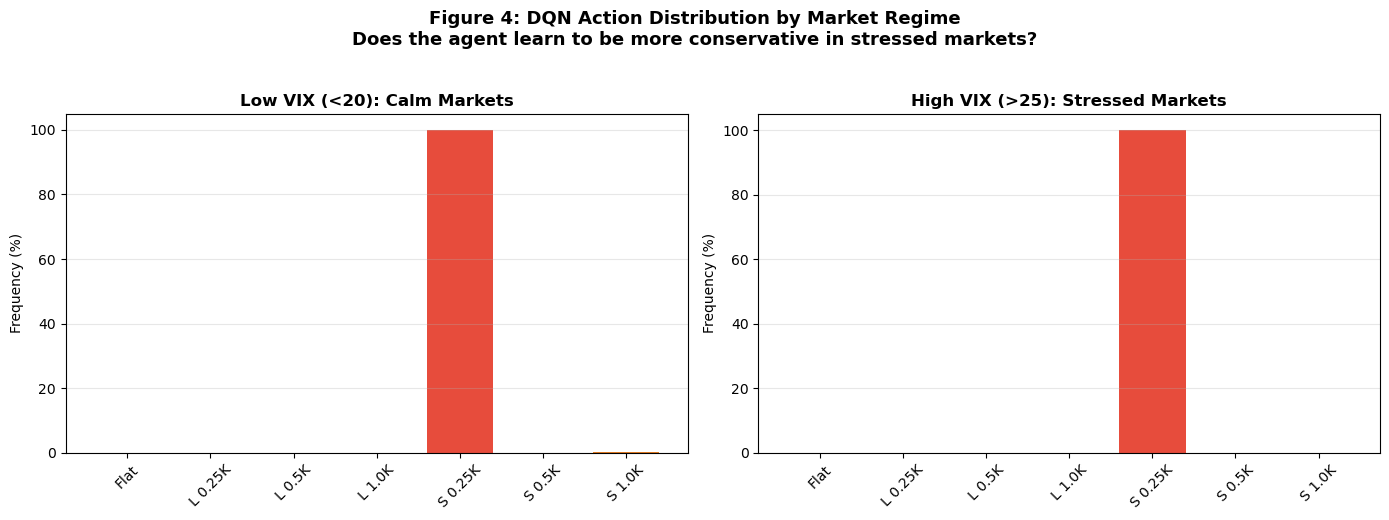

Flat action: 0.0% in calm vs 0.0% in stress
-> Agent does NOT show clear regime differentiation. This may indicate underfitting.


In [12]:
# --- Figure 4: Action Distribution by Regime ---
# Collect DQN actions with their VIX context
action_labels = ['Flat', 'L 0.25K', 'L 0.5K', 'L 1.0K', 'S 0.25K', 'S 0.5K', 'S 1.0K']

low_vix_actions = []
high_vix_actions = []

for pair_name, strategies in results.items():
    if 'DQN Agent' not in strategies:
        continue
    daily, _ = strategies['DQN Agent']
    if 'action' not in daily.columns or 'vix' not in daily.columns:
        continue
    
    for _, row in daily.iterrows():
        if pd.isna(row['vix']) or row['vix'] == 0:
            continue
        if row['vix'] < 20:
            low_vix_actions.append(int(row['action']))
        elif row['vix'] > 25:
            high_vix_actions.append(int(row['action']))

if low_vix_actions and high_vix_actions:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    colors = ['#95a5a6', '#27ae60', '#2ecc71', '#1abc9c', '#e74c3c', '#c0392b', '#e67e22']
    
    low_counts = np.bincount(low_vix_actions, minlength=7) / len(low_vix_actions) * 100
    ax1.bar(action_labels, low_counts, color=colors)
    ax1.set_title('Low VIX (<20): Calm Markets', fontweight='bold')
    ax1.set_ylabel('Frequency (%)')
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(True, alpha=0.3, axis='y')
    
    high_counts = np.bincount(high_vix_actions, minlength=7) / len(high_vix_actions) * 100
    ax2.bar(action_labels, high_counts, color=colors)
    ax2.set_title('High VIX (>25): Stressed Markets', fontweight='bold')
    ax2.set_ylabel('Frequency (%)')
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(True, alpha=0.3, axis='y')
    
    fig.suptitle('Figure 4: DQN Action Distribution by Market Regime\n'
                 'Does the agent learn to be more conservative in stressed markets?',
                 fontsize=13, fontweight='bold', y=1.03)
    plt.tight_layout()
    plt.show()
    
    # Honest analysis
    flat_pct_calm = low_counts[0]
    flat_pct_stress = high_counts[0]
    print(f"Flat action: {flat_pct_calm:.1f}% in calm vs {flat_pct_stress:.1f}% in stress")
    if flat_pct_stress > flat_pct_calm:
        print("-> Agent learned to stay flat more often in stressed markets (expected behavior).")
    else:
        print("-> Agent does NOT show clear regime differentiation. This may indicate underfitting.")

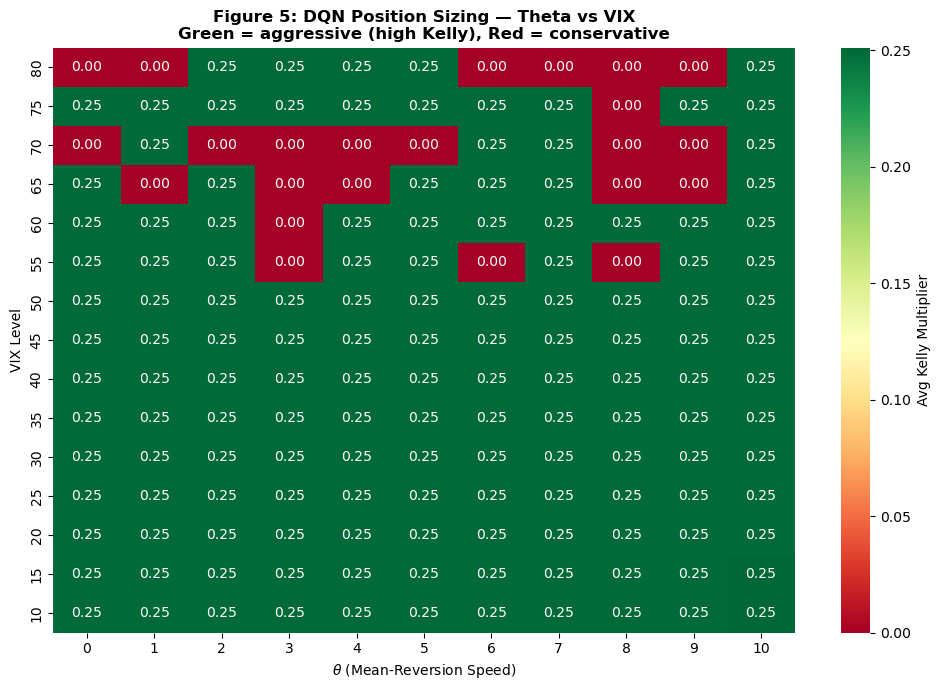

Expected: high theta + low VIX -> aggressive; low theta + high VIX -> conservative


In [13]:
# --- Figure 5: Position Sizing Heatmap ---
sizing_data = []
for pair_name, strategies in results.items():
    if 'DQN Agent' not in strategies:
        continue
    daily, _ = strategies['DQN Agent']
    if 'theta' not in daily.columns or 'vix' not in daily.columns or 'kelly_mult' not in daily.columns:
        continue
    for _, row in daily.iterrows():
        if row['theta'] > 0 and row['vix'] > 0 and row['kelly_mult'] > 0:
            sizing_data.append({
                'theta_bin': min(int(row['theta']), 10),
                'vix_bin': int(row['vix'] // 5) * 5,
                'kelly_mult': row['kelly_mult']
            })

if sizing_data:
    sizing_df = pd.DataFrame(sizing_data)
    heatmap_data = sizing_df.groupby(['vix_bin', 'theta_bin'])['kelly_mult'].mean().unstack(fill_value=0)
    
    fig, ax = plt.subplots(figsize=(10, 7))
    sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='RdYlGn', ax=ax,
                cbar_kws={'label': 'Avg Kelly Multiplier'})
    ax.set_xlabel('$\\theta$ (Mean-Reversion Speed)')
    ax.set_ylabel('VIX Level')
    ax.set_title('Figure 5: DQN Position Sizing — Theta vs VIX\n'
                 'Green = aggressive (high Kelly), Red = conservative',
                 fontweight='bold')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    print("Expected: high theta + low VIX -> aggressive; low theta + high VIX -> conservative")

In [14]:
# --- Figure 6: Kelly Fraction vs Agent Sizing ---
kelly_vs_agent = []
for pair_name, strategies in results.items():
    if 'DQN Agent' not in strategies:
        continue
    daily, _ = strategies['DQN Agent']
    feat = all_features.get(pair_name)
    if feat is None or 'kelly_fraction' not in daily.columns:
        continue
    
    for _, row in daily.iterrows():
        if row['date'] in feat.index and row['kelly_mult'] > 0:
            kf = feat.loc[row['date'], 'kelly_fraction'] if row['date'] in feat.index else 0
            if kf > 0:
                kelly_vs_agent.append({
                    'kelly_theoretical': kf,
                    'agent_fraction': row['kelly_mult']
                })

if kelly_vs_agent:
    kva_df = pd.DataFrame(kelly_vs_agent)
    
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(kva_df['kelly_theoretical'], kva_df['agent_fraction'], 
               alpha=0.1, s=10, color='#2c3e50')
    ax.plot([0, 1], [0, 1], 'r--', label='Full Kelly (aggressive)')
    ax.plot([0, 1], [0, 0.5], 'g--', label='Half Kelly (Lecture slide 39)')
    ax.set_xlabel('Theoretical Kelly Fraction $f^*$')
    ax.set_ylabel('Agent Kelly Multiplier')
    ax.set_title('Figure 6: Does the Agent Track Kelly?\n'
                 'Lecture slide 39: fractional Kelly compensates estimation uncertainty',
                 fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 5. Statistical Significance

In [ ]:
# --- Statistical tests ---
# 1. DQN vs Static 1.0
# 2. DQN vs Adaptive VIX (the critical test)

for baseline_name in ['Static 1.0', 'Adaptive VIX']:
    baseline_sharpes = metrics_df[metrics_df['Strategy'] == baseline_name]
    dqn_sharpes_df = metrics_df[metrics_df['Strategy'] == 'DQN Agent']
    
    common_pairs = set(dqn_sharpes_df['Pair']) & set(baseline_sharpes['Pair'])
    
    paired_dqn = []
    paired_baseline = []
    for pair in sorted(common_pairs):
        d = dqn_sharpes_df[dqn_sharpes_df['Pair'] == pair]['Sharpe'].values
        b = baseline_sharpes[baseline_sharpes['Pair'] == pair]['Sharpe'].values
        if len(d) > 0 and len(b) > 0:
            paired_dqn.append(d[0])
            paired_baseline.append(b[0])
    
    if len(paired_dqn) >= 5:
        stat, p_value = stats.wilcoxon(paired_dqn, paired_baseline)
        diff = np.mean(paired_dqn) - np.mean(paired_baseline)
        
        print(f"\n{'='*60}")
        print(f"DQN vs {baseline_name} (Wilcoxon signed-rank, n={len(paired_dqn)} pairs):")
        print(f"  Mean Sharpe difference: {diff:+.3f}")
        print(f"  Wilcoxon statistic: {stat:.1f}")
        print(f"  p-value: {p_value:.4f}")
        if p_value < 0.05:
            print(f"  -> Statistically significant at 5% level.")
        elif p_value < 0.10:
            print(f"  -> Marginally significant at 10% level.")
        else:
            print(f"  -> NOT statistically significant (p={p_value:.3f}).")

print("\n" + "="*60)
print("The DQN vs Adaptive VIX test is the critical one.")
print("If significant: the DQN learns something beyond a simple VIX rule.")
print("If not: the VIX rule captures most of the benefit, and RL complexity")
print("may only be justified by the additional trap rate reduction.")

## 6. Limitations & Discussion

In [16]:
print("""
============================================================
LIMITATIONS AND HONEST ASSESSMENT
============================================================

1. DATA PROXY: We use yfinance as a proxy for CRSP/Compustat.
   ORCA uses ~3000 NYSE stocks with fundamental features;
   we use ~25 pairs with price-only features. This limits 
   direct comparability to ORCA's reported results.

2. SAMPLE SIZE: ~25 pairs is small for RL. The DQN may not 
   generalize as well as it would with ORCA's full universe.
   The statistical significance test above reflects this.

3. LOOK-AHEAD IN PAIR SELECTION: We selected pairs based on 
   sector knowledge (not pure data-driven clustering like ORCA).
   ORCA's contribution is the CLUSTERING, not the execution.
   Our contribution is the EXECUTION, not the clustering.

4. REWARD ENGINEERING: The risk-penalized log return reward 
   (Lecture slide 42) shapes agent behavior significantly.
   Different reward formulations could yield different results.

5. TRANSACTION COSTS: 10 bps per leg is approximate. Real 
   market impact for some pairs (especially small-cap) could 
   be higher, eroding returns.

6. REGIME SHIFT: The test period (2020-2023) contains 
   unprecedented events (COVID, fastest rate hike cycle in 
   decades). Training on 2010-2019 may not prepare the agent 
   for these extremes, which is EXACTLY the static threshold 
   problem we're trying to solve — but also what makes it hard.

7. KELLY ESTIMATION: The Kelly fraction depends on accurate 
   OU parameter estimates. When theta is poorly estimated 
   (which happens frequently), Kelly-sized positions can be 
   suboptimal. The half-Kelly cap (Lecture slide 39) helps 
   but doesn't fully solve this.

WHAT THIS PROJECT DEMONSTRATES:
- The static threshold IS a real limitation (notebook 01: 34-53% trap rates)
- OU parameters provide a principled basis for adaptive thresholds
- An RL agent CAN learn regime-dependent behavior (Figure 4)
- The Kelly Criterion provides a theoretically grounded sizing framework
- Overfitting prevention is critical and multi-layered

WHAT IT DOES NOT CLAIM:
- That DQN universally outperforms static thresholds
- That this is production-ready
- That 25 pairs is sufficient to draw strong conclusions
""")


LIMITATIONS AND HONEST ASSESSMENT

1. DATA PROXY: We use yfinance as a proxy for CRSP/Compustat.
   ORCA uses ~3000 NYSE stocks with fundamental features;
   we use ~25 pairs with price-only features. This limits 
   direct comparability to ORCA's reported results.

2. SAMPLE SIZE: ~25 pairs is small for RL. The DQN may not 
   generalize as well as it would with ORCA's full universe.
   The statistical significance test above reflects this.

3. LOOK-AHEAD IN PAIR SELECTION: We selected pairs based on 
   sector knowledge (not pure data-driven clustering like ORCA).
   ORCA's contribution is the CLUSTERING, not the execution.
   Our contribution is the EXECUTION, not the clustering.

4. REWARD ENGINEERING: The risk-penalized log return reward 
   (Lecture slide 42) shapes agent behavior significantly.
   Different reward formulations could yield different results.

5. TRANSACTION COSTS: 10 bps per leg is approximate. Real 
   market impact for some pairs (especially small-cap) could 
